In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

## 1. 导入库和设置

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.integrate import solve_bvp as scipy_bvp, trapezoid

# 自动选择计算设备
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")

# Matplotlib配置
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

# 边界层拉伸坐标最大值
XI_MAX = 15.0

使用设备: cuda


## 2. 边界条件参数

In [3]:
def create_boundary_conditions(V, L1, L2, R1, R2):

    return {
        'V': V,      # 施加电压
        'L1': L1,    # 左边界离子1(正离子)浓度
        'L2': L2,    # 左边界离子2(负离子)浓度
        'R1': R1,    # 右边界离子1浓度
        'R2': R2     # 右边界离子2浓度
    }


def get_c_L(bc):
    """ c_L = √(L₁L₂)"""
    return np.sqrt(bc['L1'] * bc['L2'])


def get_c_R(bc):
    """ c_R = √(R₁R₂)"""
    return np.sqrt(bc['R1'] * bc['R2'])


def is_electroneutral(bc):
    """检查是否满足电中性条件"""
    return (abs(bc['L1'] - bc['L2']) < 1e-10 and 
            abs(bc['R1'] - bc['R2']) < 1e-10)


def bc_to_string(bc):
    """边界条件的字符串表示"""
    status = "电中性" if is_electroneutral(bc) else "非电中性"
    return (f"BoundaryConditions(V={bc['V']}, "
            f"Left=[{bc['L1']}, {bc['L2']}], "
            f"Right=[{bc['R1']}, {bc['R2']}]) [{status}]")

## 3. 网络构建和辅助函数

In [4]:
def make_mlp(in_dim, out_dim, hidden=64, layers=4):
    net = [nn.Linear(in_dim, hidden), nn.SiLU()]
    for _ in range(layers - 1):
        net.append(nn.Linear(hidden, hidden))
        net.append(nn.SiLU())
    net.append(nn.Linear(hidden, out_dim))
    return nn.Sequential(*net)


def grad(y, x):
    """自动微分求梯度 dy/dx"""
    return torch.autograd.grad(
        y, x, 
        grad_outputs=torch.ones_like(y), 
        create_graph=True
    )[0]


def safe_log(x, eps=1e-15):
    """安全对数运算"""
    return np.log(np.maximum(np.abs(x), eps))


def safe_div(a, b, eps=1e-12):
    """安全除法"""
    if abs(b) > eps:
        return a / b
    else:
        return 0.0


def softplus_pos(x):
    """确保正值的激活函数"""
    return nn.functional.softplus(x) + 0.01

## 4. 一阶解析解计算函数

In [5]:
class AnalyticalReference:
    """解析零阶 + 一阶修正 + 精确解"""

    def __init__(self, eps, V, L1, L2, R1, R2):
        self.eps = eps
        self.V, self.L1, self.L2, self.R1, self.R2 = V, L1, L2, R1, R2
        self.c_L = np.sqrt(L1 * L2)
        self.c_R = np.sqrt(R1 * R2)
        self.phi_L = V + 0.5 * np.log(L1 / L2)
        self.phi_R = 0.5 * np.log(R1 / R2)
        self.M = 2 * self.c_L
        self.N = 2 * self.c_R
        self.l = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
        self.r = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)

        # 零阶通量
        self.T0 = 2 * (self.c_L - self.c_R)
        if abs(self.T0) > 1e-12:
            self.I0 = self.T0 * (self.phi_R - self.phi_L) / np.log(self.c_R / self.c_L)
        else:
            self.I0 = 2 * self.c_L * (self.phi_R - self.phi_L)
        self.J10 = (self.I0 + self.T0) / 2
        self.J20 = (self.T0 - self.I0) / 2

        # 零阶外解在端点的导数
        self.dphi0_0 = -self.I0 / (2 * self.c_L)
        self.dc0_0 = -self.T0 / 2
        self.dphi0_1 = -self.I0 / (2 * self.c_R)
        self.dc0_1 = -self.T0 / 2

        # 惰性计算
        self._first_order = None
        self._exact = None

    # ---- 零阶边界层函数 ----
    def _rho_L(self, xi):
        u = self.l * np.exp(-np.sqrt(self.M) * xi)
        return (1 + u) / np.maximum(np.abs(1 - u), 1e-15)

    def _dPhi0_L(self, xi):
        u = self.l * np.exp(-np.sqrt(self.M) * xi)
        du = -np.sqrt(self.M) * u
        return 4 * du / ((1 + u) * (1 - u))

    def _C10_L(self, xi):
        return self.c_L / self._rho_L(xi)**2

    def _C20_L(self, xi):
        return self.c_L * self._rho_L(xi)**2

    def _rho_R(self, eta):
        u = self.r * np.exp(np.sqrt(self.N) * eta)
        return (1 + u) / np.maximum(np.abs(1 - u), 1e-15)

    def _dPsi0_R(self, eta):
        u = self.r * np.exp(np.sqrt(self.N) * eta)
        du = np.sqrt(self.N) * u
        return 4 * du / ((1 + u) * (1 - u))

    def _D10_R(self, eta):
        return self.c_R / self._rho_R(eta)**2

    def _D20_R(self, eta):
        return self.c_R * self._rho_R(eta)**2

    # ---- 零阶复合解 ----
    def zeroth_order(self, x):
        x = np.asarray(x)
        c0 = self.c_L - self.T0 * x / 2
        if abs(self.T0) > 1e-12:
            phi0 = (self.phi_L - (self.I0/self.T0)*np.log(self.M)
                    + (self.I0/self.T0)*np.log(np.abs(self.M - self.T0*x)))
        else:
            phi0 = self.phi_L + self.I0 * x / (2*self.c_L)

        xi = x / self.eps
        rpL = self._rho_L(np.minimum(xi, 100))
        eta = (x - 1) / self.eps
        rpR = self._rho_R(np.maximum(eta, -100))

        phi = phi0 + (self.phi_L + 2*np.log(np.abs(rpL)) - self.phi_L) + \
              (self.phi_R + 2*np.log(np.abs(rpR)) - self.phi_R)
        c1 = c0 + (self.c_L/rpL**2 - self.c_L) + (self.c_R/rpR**2 - self.c_R)
        c2 = c0 + (self.c_L*rpL**2 - self.c_L) + (self.c_R*rpR**2 - self.c_R)
        return phi, c1, c2

    # ---- 一阶修正 (BVP 求解) ----
    def compute_first_order(self):
        if self._first_order is not None:
            return self._first_order

        J10, J20 = self.J10, self.J20
        xi_bvp_max = 30.0

        # 左一阶 BVP
        def ode_L(xi, y):
            dp0 = self._dPhi0_L(xi)
            c10, c20 = self._C10_L(xi), self._C20_L(xi)
            return np.array([y[1], -(y[2]-y[3]),
                             -y[2]*dp0 - c10*y[1] - J10,
                             y[3]*dp0 + c20*y[1] - J20])

        def bc_L(ya, yb):
            return np.array([ya[0], ya[2], ya[3], yb[2]-yb[3]])

        xm = np.linspace(0, xi_bvp_max, 500)
        yi = np.zeros((4, 500))
        yi[1,:] = self.dphi0_0
        yi[2,:] = self.dc0_0 * xm
        yi[3,:] = self.dc0_0 * xm
        sol_L = scipy_bvp(ode_L, bc_L, xm, yi, tol=1e-10, max_nodes=10000)
        assert sol_L.success, f"左 BVP 失败: {sol_L.message}"

        yL = sol_L.sol(xi_bvp_max)
        phi1_0 = yL[0] - xi_bvp_max * self.dphi0_0
        c1_0 = yL[2] - xi_bvp_max * self.dc0_0

        # 右一阶 BVP
        def ode_R(eta, y):
            dp0 = self._dPsi0_R(eta)
            d10, d20 = self._D10_R(eta), self._D20_R(eta)
            return np.array([y[1], -(y[2]-y[3]),
                             -y[2]*dp0 - d10*y[1] - J10,
                             y[3]*dp0 + d20*y[1] - J20])

        def bc_R(ya, yb):
            return np.array([yb[0], yb[2], yb[3], ya[2]-ya[3]])

        em = np.linspace(-xi_bvp_max, 0, 500)
        yi_R = np.zeros((4, 500))
        yi_R[1,:] = self.dphi0_1
        yi_R[2,:] = self.dc0_1 * em
        yi_R[3,:] = self.dc0_1 * em
        sol_R = scipy_bvp(ode_R, bc_R, em, yi_R, tol=1e-10, max_nodes=10000)
        assert sol_R.success, f"右 BVP 失败: {sol_R.message}"

        yR = sol_R.sol(-xi_bvp_max)
        phi1_1 = yR[0] - (-xi_bvp_max) * self.dphi0_1
        c1_1 = yR[2] - (-xi_bvp_max) * self.dc0_1

        # 确定 T₁, I₁
        T1 = 2 * (c1_0 - c1_1)
        xq = np.linspace(0, 1, 10000)
        c0q = self.c_L - self.T0 * xq / 2
        c1q = c1_0 - T1 * xq / 2
        A = trapezoid(1/(2*c0q), xq)
        B = trapezoid(c1q/(2*c0q**2), xq)
        I1 = (self.I0 * B - (phi1_1 - phi1_0)) / A

        # 一阶外解 φ₁: 由式 (13) 消去 c₁₁ 得 φ₁' = (I₀c₁₁/c₀ − I₁)/(2c₀)
        dphi1q = (self.I0 * c1q / c0q - I1) / (2 * c0q)
        phi1_grid = phi1_0 + np.concatenate(
            [[0.0], np.cumsum(0.5 * (dphi1q[1:] + dphi1q[:-1]) * np.diff(xq))])

        self._first_order = {
            'phi1_0': phi1_0, 'phi1_1': phi1_1,
            'c1_0': c1_0, 'c1_1': c1_1,
            'T1': T1, 'I1': I1,
            'J11': (I1+T1)/2, 'J21': (T1-I1)/2,
            'sol_L': sol_L, 'sol_R': sol_R,
            'xi_bvp_max': xi_bvp_max,
            'xq': xq, 'phi1_grid': phi1_grid,
        }
        return self._first_order

    # ---- 一阶复合解 (Van Dyke) ----
    def first_order(self, x):
        """
        一阶 Van Dyke 复合解, 对应式 (34)-(35)

            u = [u₀ᵒ(x) + ε·u₁ᵒ(x)]
              + [内解零阶 − 远场极限] + ε·[内解一阶 − 远场渐近线]   (左右两端各一份)

        内解一阶减去其远场渐近线后随 |z| 指数衰减, 因此超出 [0, ξ_max] 的部分
        夹断为 0; 在 z = ξ_max 处该差值恰为 0, 拼接是连续的。
        """
        x = np.asarray(x)
        fo = self.compute_first_order()
        eps, XM = self.eps, fo['xi_bvp_max']

        # 零阶复合解
        phi, c1, c2 = self.zeroth_order(x)

        # 一阶外解
        c11 = fo['c1_0'] - fo['T1'] * x / 2
        phi1 = np.interp(x, fo['xq'], fo['phi1_grid'])

        # 左端一阶内解 − 远场渐近线
        xi = np.minimum(x / eps, XM)
        yL = fo['sol_L'].sol(xi)
        dphi_L = yL[0] - (fo['phi1_0'] + self.dphi0_0 * xi)
        dc1_L = yL[2] - (fo['c1_0'] + self.dc0_0 * xi)
        dc2_L = yL[3] - (fo['c1_0'] + self.dc0_0 * xi)

        # 右端一阶内解 − 远场渐近线
        eta = np.maximum((x - 1) / eps, -XM)
        yR = fo['sol_R'].sol(eta)
        dphi_R = yR[0] - (fo['phi1_1'] + self.dphi0_1 * eta)
        dc1_R = yR[2] - (fo['c1_1'] + self.dc0_1 * eta)
        dc2_R = yR[3] - (fo['c1_1'] + self.dc0_1 * eta)

        return (phi + eps * (phi1 + dphi_L + dphi_R),
                c1 + eps * (c11 + dc1_L + dc1_R),
                c2 + eps * (c11 + dc2_L + dc2_R))

    # ---- 支持 ε 延拓的精确解 ----
    def compute_exact_continuation(self, guess=None, tol=1e-8, max_nodes=200000):
        """
        完整 PNP 系统的数值解, 支持 ε 延拓

        参数:
            guess: (x, y) 上一个较大 ε 的解, 作为本次初值; 缺省用零阶复合解
        说明:
            ε ≲ 10⁻⁴ 时 solve_bvp 可能达不到容差, 此时给出警告并沿用当前解;
            其残差仍远小于神经网络误差, 不影响 E_net 与 E_total 的判读。
        """
        if self._exact is not None:
            return self._exact

        eps = self.eps

        def pnp_ode(x, y):
            phi, dphi, c1, c2, J1v, J2v = y
            return np.vstack([dphi, -(c1-c2)/eps**2, -c1*dphi-J1v,
                              c2*dphi-J2v, np.zeros_like(x), np.zeros_like(x)])

        def pnp_bc(ya, yb):
            return np.array([ya[0]-self.V, yb[0], ya[2]-self.L1,
                             yb[2]-self.R1, ya[3]-self.L2, yb[3]-self.R2])

        if guess is None:
            x_init = np.linspace(0, 1, 5000)
            phi0, c1_0, c2_0 = self.zeroth_order(x_init)
            y0 = np.zeros((6, len(x_init)))
            y0[0] = phi0
            y0[1] = np.gradient(phi0, x_init)
            y0[2] = np.maximum(c1_0, 0.01)
            y0[3] = np.maximum(c2_0, 0.01)
            y0[4] = self.J10
            y0[5] = self.J20
        else:
            x_init, y0 = guess

        sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=tol, max_nodes=max_nodes)
        if not sol.success:
            print(f'    [警告] ε={eps:g} 精确解未达容差 '
                  f'(最大 rms 残差 {sol.rms_residuals.max():.1e}), 予以采用')
        self._exact = sol
        return sol

    # ---- 精确 BVP 解 ----
    def compute_exact(self):
        if self._exact is not None:
            return self._exact

        eps = self.eps

        def pnp_ode(x, y):
            phi, dphi, c1, c2, J1v, J2v = y
            return np.vstack([dphi, -(c1-c2)/eps**2, -c1*dphi-J1v,
                              c2*dphi-J2v, np.zeros_like(x), np.zeros_like(x)])

        def pnp_bc(ya, yb):
            return np.array([ya[0]-self.V, yb[0], ya[2]-self.L1,
                             yb[2]-self.R1, ya[3]-self.L2, yb[3]-self.R2])

        x_init = np.linspace(0, 1, 5000)
        phi0, c1_0, c2_0 = self.zeroth_order(x_init)
        y0 = np.zeros((6, len(x_init)))
        y0[0] = phi0
        y0[1] = np.gradient(phi0, x_init)
        y0[2] = c1_0
        y0[3] = c2_0
        y0[4] = self.J10
        y0[5] = self.J20

        sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
        assert sol.success, f"精确解 BVP 失败: {sol.message}"
        self._exact = sol
        return sol

    def exact_solution(self, x):
        sol = self.compute_exact()
        y = sol.sol(x)
        return y[0], y[2], y[3], y[4,0], y[5,0]

## 5. PVD-Net 神经网络（一阶）

In [6]:
def create_pvdnet(eps, hidden=100, layers=5, device=DEVICE):
    """
    创建一阶 PVD-Net 模型
    
    网络组成:
      - outer_0, outer_1: 零阶/一阶外部解网络, x → (φ, c)
      - L0, R0: 零阶左/右内部解网络, ξ/η → (Φ, C₁, C₂)
      - Lc, Rc: 一阶线性增长系数网络
      - L1, R1: 一阶衰减项网络
      - J10, J20: 零阶通量参数
      - J11, J21: 一阶通量参数
    """
    model = {
        'eps': eps,
        'device': device,
        'outer': {},
        'inner': {},
        'flux_params': []
    }
    
    # 外部解网络 (零阶 + 一阶)
    model['outer']['0'] = make_mlp(1, 2, hidden, layers).to(device)
    model['outer']['1'] = make_mlp(1, 2, hidden, layers).to(device)
    
    # 内部解网络
    for key in ['L0', 'Lc', 'L1', 'R0', 'Rc', 'R1']:
        model['inner'][key] = make_mlp(1, 3, hidden, layers).to(device)
    
    # 通量参数 (可学习)
    model['flux_params'].append(nn.Parameter(torch.tensor([0.1], device=device)))   # J1_0
    model['flux_params'].append(nn.Parameter(torch.tensor([0.1], device=device)))   # J2_0
    model['flux_params'].append(nn.Parameter(torch.tensor([0.0], device=device)))   # J1_1
    model['flux_params'].append(nn.Parameter(torch.tensor([0.0], device=device)))   # J2_1
    
    # 初始化权重
    for key in model['outer']:
        for m in model['outer'][key].modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
    for key in model['inner']:
        for m in model['inner'][key].modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
    
    return model


'''
解析解                              神经网络
──────────────────────────────────────────────────
零阶外解 φ₀(x), c₀(x)           ←→  outer['0']: x → (φ, c)
一阶外解 φ₁(x), c₁(x)           ←→  outer['1']: x → (φ, c)
零阶左内解 Φ₀(ξ), C₁₀, C₂₀      ←→  inner['L0']: ξ → (Φ, C₁, C₂)
零阶右内解 Ψ₀(η), D₁₀, D₂₀      ←→  inner['R0']: η → (Ψ, D₁, D₂)
一阶左内解系数 + 衰减项           ←→  inner['Lc'] + inner['L1']
一阶右内解系数 + 衰减项           ←→  inner['Rc'] + inner['R1']
通量 J₁₀, J₂₀, J₁₁, J₂₁        ←→  flux_params[0..3]
'''


def get_all_parameters(model):
    """获取所有可训练参数"""
    params = []
    for net in model['outer'].values():
        params.extend(net.parameters())
    for net in model['inner'].values():
        params.extend(net.parameters())
    params.extend(model['flux_params'])
    return params


def get_flux(model):
    """获取通量值"""
    return (model['flux_params'][0].item(), model['flux_params'][1].item(),
            model['flux_params'][2].item(), model['flux_params'][3].item())


def _eval_inner(net, z, clamp_lo, clamp_hi, pos_mask=(False, False, False)):
    """内部网络前向传播 (带 clamp 和正值约束)"""
    zc = z.clamp(clamp_lo, clamp_hi)
    out = net(zc)
    cols = []
    for i in range(3):
        c = out[:, i:i+1]
        cols.append(softplus_pos(c) if pos_mask[i] else c)
    return cols


def get_outer_solution(model, x, order):
    """获取外部解: x → (φ, c₁, c₂), 其中 c₁ = c₂ = c (电中性)"""
    out = model['outer'][str(order)](x)
    phi, c = out[:, 0:1], out[:, 1:2]
    if order == 0:
        c = softplus_pos(c)
    return phi, c, c


def get_inner_solution(model, z, side, order='0'):
    """
    获取内部(边界层)解
    order='0': 零阶, order='c': 线性系数, order='1': 衰减项
    """
    key = side + order
    net = model['inner'][key]
    lo, hi = (0, XI_MAX) if side == 'L' else (-XI_MAX, 0)
    pos = (False, True, True) if order == '0' else (False, False, False)
    return _eval_inner(net, z, lo, hi, pos)


def get_full_inner_1(model, z, side):
    """获取完整一阶内部解: z·c(z) + d(z)"""
    fc = get_inner_solution(model, z, side, 'c')
    fd = get_inner_solution(model, z, side, '1')
    return [z * c + d for c, d in zip(fc, fd)]


def _bl_correction(model, z, z_far, side, order):
    """计算边界层修正项 (内解 - 远场匹配值)"""
    if order == 0:
        vals = get_inner_solution(model, z, side, '0')
        vals_far = get_inner_solution(model, z_far, side, '0')
        return [v - vf for v, vf in zip(vals, vals_far)]
    else:
        fc = get_inner_solution(model, z, side, 'c')
        fc_far = get_inner_solution(model, z_far, side, 'c')
        fd = get_inner_solution(model, z, side, '1')
        fd_far = get_inner_solution(model, z_far, side, '1')
        return [z * (c - cf) + (d - df)
                for c, cf, d, df in zip(fc, fc_far, fd, fd_far)]


def forward_pvdnet(model, x):
    """
    计算一阶复合解 (Van Dyke 匹配)
    
    复合解 = (外部零阶 + ε·外部一阶)
           + 左边界层零阶修正 + ε·左边界层一阶修正
           + 右边界层零阶修正 + ε·右边界层一阶修正
    """
    eps = model['eps']
    dev = model['device']
    xi, eta = x / eps, (x - 1.0) / eps
    xi_far = torch.tensor([[XI_MAX]], device=dev)
    eta_far = torch.tensor([[-XI_MAX]], device=dev)

    # 外部解
    o0 = get_outer_solution(model, x, 0)
    o1 = get_outer_solution(model, x, 1)

    # 边界层修正
    dL0 = _bl_correction(model, xi, xi_far, 'L', 0)
    dL1 = _bl_correction(model, xi, xi_far, 'L', 1)
    dR0 = _bl_correction(model, eta, eta_far, 'R', 0)
    dR1 = _bl_correction(model, eta, eta_far, 'R', 1)

    # 组装复合解
    result = []
    for i in range(3):
        result.append(
            (o0[i] + eps * o1[i])
            + dL0[i] + eps * dL1[i]
            + dR0[i] + eps * dR1[i]
        )
    return result

## 6. 损失函数

In [7]:
def sample_points(n, device):
    """在 [0,1] 上采样配点"""
    return torch.rand(n, 1, device=device).requires_grad_(True)


def outer_pde_loss(model, x, order):
    """
    外部 PDE 残差
    
    零阶: 2ċ₀ + T₀ = 0,  2c₀φ̇₀ + I₀ = 0
    一阶: 2ċ₁ + T₁ = 0,  2(c₁φ̇₀ + c₀φ̇₁) + I₁ = 0
    """
    J10, J20 = model['flux_params'][0], model['flux_params'][1]
    J11, J21 = model['flux_params'][2], model['flux_params'][3]
    
    phi0, c0, _ = get_outer_solution(model, x, 0)
    dphi0, dc0 = grad(phi0, x), grad(c0, x)
    
    if order == 0:
        T, I = J10 + J20, J10 - J20
        r1 = 2 * dc0 + T
        r2 = 2 * c0 * dphi0 + I
    else:
        phi1, c1, _ = get_outer_solution(model, x, 1)
        dphi1, dc1 = grad(phi1, x), grad(c1, x)
        T, I = J11 + J21, J11 - J21
        r1 = 2 * dc1 + T
        r2 = 2 * (c1 * dphi0 + c0 * dphi1) + I
    
    return torch.mean(r1**2 + r2**2)


def inner_pde_loss_0(model, z, side):
    """
    零阶内部 PDE 残差 (Eq. 3.4)
    
    Φ'' + C₁ - C₂ = 0
    C₁' + C₁Φ' = 0
    C₂' - C₂Φ' = 0
    """
    P, C1, C2 = get_inner_solution(model, z, side, '0')
    dP, dC1, dC2 = grad(P, z), grad(C1, z), grad(C2, z)
    ddP = grad(dP, z)
    return torch.mean((ddP + C1 - C2)**2 + (dC1 + C1*dP)**2 + (dC2 - C2*dP)**2)


def inner_pde_loss_1(model, z, side):
    """
    一阶内部 PDE 残差
    
    Φ₁'' + C₁₁ - C₂₁ = 0
    C₁₁' + C₁₁Φ₀' + C₁₀Φ₁' + J₁₀ = 0
    C₂₁' - C₂₁Φ₀' - C₂₀Φ₁' + J₂₀ = 0
    """
    J10 = model['flux_params'][0]
    J20 = model['flux_params'][1]
    
    P0, C10, C20 = get_inner_solution(model, z, side, '0')
    dP0 = grad(P0, z)
    P1, C11, C21 = get_full_inner_1(model, z, side)
    dP1, dC11, dC21 = grad(P1, z), grad(C11, z), grad(C21, z)
    ddP1 = grad(dP1, z)
    
    r1 = ddP1 + C11 - C21
    r2 = dC11 + C11*dP0 + C10*dP1 + J10
    r3 = dC21 - C21*dP0 - C20*dP1 + J20
    return torch.mean(r1**2 + r2**2 + r3**2)


def boundary_loss(model, V, L1, L2, R1, R2):
    """边界条件损失 (零阶 + 一阶)"""
    z0 = torch.zeros(1, 1, device=model['device'])
    
    # 零阶边界: 左 φ(0)=V, c₁(0)=L₁, c₂(0)=L₂; 右 φ(1)=0, c₁(1)=R₁, c₂(1)=R₂
    PL, C1L, C2L = get_inner_solution(model, z0, 'L', '0')
    PR, C1R, C2R = get_inner_solution(model, z0, 'R', '0')
    loss_0 = ((PL-V)**2 + (C1L-L1)**2 + (C2L-L2)**2
              + PR**2 + (C1R-R1)**2 + (C2R-R2)**2)
    
    # 一阶边界: 衰减项在 z=0 处为零
    PL1, CL1a, CL1b = get_inner_solution(model, z0, 'L', '1')
    PR1, CR1a, CR1b = get_inner_solution(model, z0, 'R', '1')
    loss_1 = PL1**2 + CL1a**2 + CL1b**2 + PR1**2 + CR1a**2 + CR1b**2
    
    return (loss_0 + loss_1).mean()


def matching_loss(model):
    """Van Dyke 匹配损失: 内解远场 ↔ 外解端点值及导数"""
    dev = model['device']
    xi_f = torch.tensor([[XI_MAX]], device=dev)
    eta_f = torch.tensor([[-XI_MAX]], device=dev)
    x0 = torch.zeros(1, 1, device=dev, requires_grad=True)
    x1 = torch.ones(1, 1, device=dev, requires_grad=True)

    loss = torch.tensor(0.0, device=dev)

    # 外解在端点的值和导数
    p0_0, c0_0, _ = get_outer_solution(model, x0, 0)
    p0_1, c0_1, _ = get_outer_solution(model, x1, 0)
    dp0_0, dc0_0 = grad(p0_0, x0), grad(c0_0, x0)
    dp0_1, dc0_1 = grad(p0_1, x1), grad(c0_1, x1)
    p1_0, c1_0, _ = get_outer_solution(model, x0, 1)
    p1_1, c1_1, _ = get_outer_solution(model, x1, 1)

    for side, zf, p_val, c_val, dp_val, dc_val, p1_val, c1_val in [
        ('L', xi_f, p0_0, c0_0, dp0_0, dc0_0, p1_0, c1_0),
        ('R', eta_f, p0_1, c0_1, dp0_1, dc0_1, p1_1, c1_1),
    ]:
        i0 = get_inner_solution(model, zf, side, '0')
        ic = get_inner_solution(model, zf, side, 'c')
        i1d = get_inner_solution(model, zf, side, '1')

        # 零阶匹配: 内解远场 ↔ 外解端点
        loss = loss + (i0[0] - p_val)**2 + (i0[1] - c_val)**2 + (i0[2] - c_val)**2
        # 一阶线性系数匹配: 内解增长率 ↔ 外解导数
        loss = loss + (ic[0] - dp_val)**2 + (ic[1] - dc_val)**2 + (ic[2] - dc_val)**2
        # 一阶衰减项匹配: 远场衰减值 ↔ 外解一阶端点
        loss = loss + (i1d[0] - p1_val)**2 + (i1d[1] - c1_val)**2 + (i1d[2] - c1_val)**2

    return loss.mean()


def compute_loss(model, V, L1, L2, R1, R2):
    """
    一阶总损失函数 (7 项)
    
    = outer_0 + outer_1 + inner_0 + inner_1
      + 10×match + 50×bc + 20×farfield
    """
    dev = model['device']
    x_o = sample_points(200, dev)
    xi = (torch.rand(150, 1, device=dev) * XI_MAX).requires_grad_(True)
    eta = (-torch.rand(150, 1, device=dev) * XI_MAX).requires_grad_(True)

    losses = {
        'outer_0': outer_pde_loss(model, x_o, 0),
        'outer_1': outer_pde_loss(model, x_o, 1),
        'inner_0': inner_pde_loss_0(model, xi, 'L') + inner_pde_loss_0(model, eta, 'R'),
        'inner_1': inner_pde_loss_1(model, xi, 'L') + inner_pde_loss_1(model, eta, 'R'),
        'match':   matching_loss(model),
        'bc':      boundary_loss(model, V, L1, L2, R1, R2),
    }

    total = (losses['outer_0'] + losses['outer_1']
             + losses['inner_0'] + losses['inner_1']
             + 10 * losses['match'] + 50 * losses['bc'])

    return total, {k: v.item() for k, v in losses.items()}

## 7. 训练函数

In [8]:
def train(model, V, L1, L2, R1, R2, epochs=80000, log_interval=1000):
    """
    训练一阶 PVD-Net 模型
    
    返回: 训练历史
    """
    params = get_all_parameters(model)
    optimizer = torch.optim.Adam(params, lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs, eta_min=1e-6
    )
    
    history = {'loss': [], 'J1': [], 'J2': []}
    best_loss = float('inf')                                
    best_state = [p.data.clone() for p in params]           
    
    for ep in range(epochs):
        optimizer.zero_grad()
        loss, details = compute_loss(model, V, L1, L2, R1, R2)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        
        optimizer.step()
        scheduler.step()
        if loss.item() < best_loss:                         
            best_loss = loss.item()                         
            best_state = [p.data.clone() for p in params]   
        
        J10, J20, J11, J21 = get_flux(model)
        history['loss'].append(loss.item())
        history['J1'].append(J10)
        history['J2'].append(J20)
        
        if (ep + 1) % log_interval == 0:
            print(f"Epoch {ep+1:6d}/{epochs} | Loss: {loss.item():.4e} | "
                  f"J10={J10:.4f}, J20={J20:.4f}, J11={J11:.4f}, J21={J21:.4f}")
    
    for p, b in zip(params, best_state):                    
        p.data.copy_(b)                                     
    
    print(f'训练完成! 最佳损失: {best_loss:.4e}')            
    return history

## 8. 主程序：设置参数

In [9]:
# ============================================================
# ============================================================
sigma, rho = 1/3, 2/3
L_bath, R_bath = 2.4, 1.8

# 物理参数设置
eps = 1e-2    # Debye长度参数
V = 1.0       # 施加电压

# 边界浓度 (非电中性情形)
L1 = 0.8
L2 = 2.4
R1 = 1.2
R2 = 1.8

print('  1st-order PVD-Net for PNP System')
print(f"  ε = {eps},  V = {V}")
print(f"  Left BC:  L1 = {L1}, L2 = {L2}")
print(f"  Right BC: R1 = {R1}, R2 = {R2}")

bc = create_boundary_conditions(V, L1, L2, R1, R2)
print(f"  {bc_to_string(bc)}")

assert abs(L1 - sigma*L_bath) < 1e-12 and abs(R1 - rho*R_bath) < 1e-12
print(f"  σ = {sigma}, ρ = {rho}, L = {L_bath}, R = {R_bath}")
print(f"  L1 - L2 = {L1-L2:+.2f},  R1 - R2 = {R1-R2:+.2f}   (两端均非电中性)")


  1st-order PVD-Net for PNP System
  ε = 0.01,  V = 1.0
  Left BC:  L1 = 0.8, L2 = 2.4
  Right BC: R1 = 1.2, R2 = 1.8
  BoundaryConditions(V=1.0, Left=[0.8, 2.4], Right=[1.2, 1.8]) [非电中性]
  σ = 0.3333333333333333, ρ = 0.6666666666666666, L = 2.4, R = 1.8
  L1 - L2 = -1.60,  R1 - R2 = -0.60   (两端均非电中性)


## 9. 构建和训练模型

In [10]:
# 构建模型
hidden = 33
epochs = 300000

# 计算解析参考值
ref = AnalyticalReference(eps, V, L1, L2, R1, R2)
fo = ref.compute_first_order()

print(f"解析参考值:")
print(f"  J10={ref.J10:.6f}, J20={ref.J20:.6f}")
print(f"  J11={fo['J11']:.6f}, J21={fo['J21']:.6f}")

model = create_pvdnet(eps, hidden=hidden, layers=5, device=DEVICE)

param_count = sum(p.numel() for p in get_all_parameters(model))
print(f"\n模型参数量: {param_count:,}")

解析参考值:
  J10=0.848553, J20=-1.016659
  J11=-0.495713, J21=-0.339779

模型参数量: 37,184


In [11]:
# 训练模型
# 训练模型
import time

start_time = time.time()
history = train(model, V, L1, L2, R1, R2, epochs=epochs, log_interval=500)
end_time = time.time() # 记录结束时间

print(f"程序运行时间：{end_time - start_time} 秒")

Epoch    500/300000 | Loss: 2.7943e-02 | J10=0.0132, J20=0.0005, J11=0.0020, J21=0.0006
Epoch   1000/300000 | Loss: 1.8743e-02 | J10=0.0087, J20=-0.0201, J11=0.0002, J21=0.0000
Epoch   1500/300000 | Loss: 1.1366e-02 | J10=0.0234, J20=-0.0461, J11=0.0011, J21=-0.0008
Epoch   2000/300000 | Loss: 1.2761e-02 | J10=0.0636, J20=-0.0979, J11=0.0330, J21=-0.0293
Epoch   2500/300000 | Loss: 1.1043e-02 | J10=0.1087, J20=-0.1567, J11=0.0262, J21=-0.0317
Epoch   3000/300000 | Loss: 6.2314e-03 | J10=0.1850, J20=-0.2568, J11=0.0423, J21=-0.0574
Epoch   3500/300000 | Loss: 2.7573e-02 | J10=0.2639, J20=-0.3391, J11=0.0493, J21=-0.0850
Epoch   4000/300000 | Loss: 1.5808e-02 | J10=0.3291, J20=-0.4119, J11=0.0521, J21=-0.0820
Epoch   4500/300000 | Loss: 4.3771e-03 | J10=0.3773, J20=-0.4817, J11=0.0431, J21=-0.0675
Epoch   5000/300000 | Loss: 2.4178e-03 | J10=0.4444, J20=-0.5624, J11=0.0458, J21=-0.0788
Epoch   5500/300000 | Loss: 3.1794e-03 | J10=0.5110, J20=-0.6421, J11=0.0409, J21=-0.0883
Epoch   6000/

## 10. 统一评估: 以精确 BVP 解为基准

**目的**: 用 scipy `solve_bvp` 求完整 PNP 系统的精确数值解作为统一参考基准, 计算 6 项误差指标。
该指标体系与零阶 PVD-Net 完全一致, 使两者可以公平对比。

In [12]:
from scipy.integrate import solve_bvp as scipy_bvp, trapezoid

def compute_exact_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    """
    用 scipy solve_bvp 求完整 PNP 系统的精确数值解
    作为零阶和一阶的统一评价基准
    """
    c_L = np.sqrt(L1 * L2)
    c_R = np.sqrt(R1 * R2)
    phi_L = V + 0.5 * np.log(L1 / L2)
    phi_R = 0.5 * np.log(R1 / R2)
    M = 2 * c_L
    T0 = 2 * (c_L - c_R)
    if abs(T0) > 1e-12:
        I0 = T0 * (phi_R - phi_L) / np.log(c_R / c_L)
    else:
        I0 = 2 * c_L * (phi_R - phi_L)
    J10 = (I0 + T0) / 2
    J20 = (T0 - I0) / 2
    l_param = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
    r_param = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)
    N = 2 * c_R

    # 零阶复合解作初始猜测
    x_init = np.linspace(0, 1, n_init)
    c0 = c_L - T0 * x_init / 2
    if abs(T0) > 1e-12:
        phi0 = phi_L - (I0/T0)*np.log(M) + (I0/T0)*np.log(np.abs(M - T0*x_init))
    else:
        phi0 = phi_L + I0 * x_init / (2*c_L)

    xi = x_init / eps
    u_L = l_param * np.exp(-np.sqrt(M) * np.minimum(xi, 100))
    rpL = (1 + u_L) / np.maximum(np.abs(1 - u_L), 1e-15)
    eta = (x_init - 1) / eps
    u_R = r_param * np.exp(np.sqrt(N) * np.maximum(eta, -100))
    rpR = (1 + u_R) / np.maximum(np.abs(1 - u_R), 1e-15)

    phi_guess = phi0 + 2*np.log(np.abs(rpL)) + 2*np.log(np.abs(rpR))
    c1_guess = np.maximum(c0 + (c_L/rpL**2 - c_L) + (c_R/rpR**2 - c_R), 0.01)
    c2_guess = np.maximum(c0 + (c_L*rpL**2 - c_L) + (c_R*rpR**2 - c_R), 0.01)

    y0 = np.zeros((6, n_init))
    y0[0] = phi_guess
    y0[1] = np.gradient(phi_guess, x_init)
    y0[2] = c1_guess
    y0[3] = c2_guess
    y0[4] = J10
    y0[5] = J20

    def pnp_ode(x, y):
        phi, E, c1, c2, J1, J2 = y
        return np.vstack([E, -(c1 - c2)/eps**2,
                          -c1*E - J1, c2*E - J2,
                          np.zeros_like(x), np.zeros_like(x)])

    def pnp_bc(ya, yb):
        return np.array([ya[0]-V, yb[0], ya[2]-L1, yb[2]-R1, ya[3]-L2, yb[3]-R2])

    sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f'精确解求解失败: {sol.message}'
    return sol


In [13]:
def create_evaluation_grid(eps, n_inner_per_side=2500, n_outer=200):
    """按论文方式创建分区评估网格"""
    bl_w = min(10 * eps, 0.05)  # 边界层宽度
    
    # 左边界层: [0, bl_w] 密集采点
    x_left_bl = np.linspace(0, bl_w, n_inner_per_side, endpoint=False)
    
    # 右边界层: [1-bl_w, 1] 密集采点
    x_right_bl = np.linspace(1 - bl_w, 1, n_inner_per_side, endpoint=True)
    
    # 交界点
    x_junction = np.array([bl_w, 1 - bl_w])
    
    # 外区域: (bl_w, 1-bl_w) 均匀采点
    x_outer = np.linspace(bl_w, 1 - bl_w, n_outer + 2)[1:-1]  # 去掉端点避免重复
    
    # 合并并排序
    x_all = np.sort(np.unique(np.concatenate([x_left_bl, x_right_bl, x_junction, x_outer])))
    
    # 记录各区域的索引掩码
    return {
        'x': x_all,
        'n': len(x_all),
        'bl_width': bl_w,
        'eps': eps,
        'mask_left_bl': x_all <= bl_w,
        'mask_right_bl': x_all >= 1 - bl_w,
        'mask_inner': (x_all <= bl_w) | (x_all >= 1 - bl_w),       # 所有边界层点
        'mask_outer': (x_all > bl_w) & (x_all < 1 - bl_w),          # 外区域
        'junction_left': np.argmin(np.abs(x_all - bl_w)),            # 左交界点索引
        'junction_right': np.argmin(np.abs(x_all - (1 - bl_w))),     # 右交界点索引
    }


def compute_unified_metrics(phi_a, c1_a, c2_a, J1_a, J2_a,
                            phi_e, c1_e, c2_e, J1_e, J2_e, grids):
    """
    按论文 Table 2 的五项指标评估:
    ① 全局相对 L²   ② 全局 L∞
    ③ 内区域相对 L²  ④ 内区域 L∞
    ⑤ 交界点误差
    """
    x = grids['x']
    mask_inner = grids['mask_inner']
    mask_left_bl = grids['mask_left_bl']
    mask_right_bl = grids['mask_right_bl']
    jL = grids['junction_left']
    jR = grids['junction_right']
    
    results = {}
    for name, ua, ue in [('phi', phi_a, phi_e), ('c1', c1_a, c1_e), ('c2', c2_a, c2_e)]:
        err = np.abs(ua - ue)
        
        # ① 全局相对 L²
        norm_e = np.sqrt(trapezoid(ue**2, x))
        norm_err = np.sqrt(trapezoid(err**2, x))
        global_rel_L2 = norm_err / max(norm_e, 1e-16)
        
        # ② 全局 L∞
        global_Linf = np.max(err)
        
        # ③ 内区域（边界层）相对 L²
        # 左右两段是不相连的区间，必须分别积分后相加。若直接对拼接后的节点
        # 数组调用 trapezoid，会在 w_BL 与 1-w_BL 之间多出一段宽度
        # (1-2*w_BL) 的伪梯形，分子分母同时被污染。
        def _int_sq(v, m):
            return trapezoid(v[m]**2, x[m]) if np.count_nonzero(m) > 1 else 0.0
        den_sq = _int_sq(ue, mask_left_bl) + _int_sq(ue, mask_right_bl)
        num_sq = _int_sq(err, mask_left_bl) + _int_sq(err, mask_right_bl)
        if den_sq > 0.0:
            inner_rel_L2 = np.sqrt(num_sq) / max(np.sqrt(den_sq), 1e-16)
        else:
            inner_rel_L2 = np.nan
        
        # ④ 内区域 L∞
        inner_Linf = np.max(err[mask_inner]) if np.any(mask_inner) else np.nan
        
        # ⑤ 交界点误差 (取左右交界点的最大误差)
        junction_err = max(err[jL], err[jR])
        
        results[name] = {
            'global_rel_L2': global_rel_L2,
            'global_Linf': global_Linf,
            'inner_rel_L2': inner_rel_L2,
            'inner_Linf': inner_Linf,
            'junction_err': junction_err,
        }
    
    # 通量和电流指标保持不变
    results['flux'] = {
        'J1_rel_err': abs(J1_a - J1_e) / max(abs(J1_e), 1e-16),
        'J2_rel_err': abs(J2_a - J2_e) / max(abs(J2_e), 1e-16),
    }
    I_a, I_e = J1_a - J2_a, J1_e - J2_e
    results['current'] = {
        'I_rel_err': abs(I_a - I_e) / max(abs(I_e), 1e-16),
        'I_approx': I_a, 'I_exact': I_e,
    }
    return results


def print_unified_table(metrics, method_name, eps):
    print(f'  统一评估: {method_name}  (ε = {eps})')
    print(f'  参考解: 完整 PNP 系统 scipy BVP 精确数值解')
    print(f"  {'指标':<22s} | {'phi':>12s} | {'c1':>12s} | {'c2':>12s}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    for mk, ml in [('global_rel_L2', '① 全局相对 L²'),
                    ('global_Linf',   '② 全局 L∞'),
                    ('inner_rel_L2',  '③ 内区域相对 L²'),
                    ('inner_Linf',    '④ 内区域 L∞'),
                    ('junction_err',  '⑤ 交界点误差')]:
        vals = [metrics[v][mk] for v in ['phi', 'c1', 'c2']]
        print(f"  {ml:<22s} | {vals[0]:>12.4e} | {vals[1]:>12.4e} | {vals[2]:>12.4e}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    print(f"\n  I_approx = {metrics['current']['I_approx']:.6f},  I_exact = {metrics['current']['I_exact']:.6f}")


def plot_vs_exact(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex, eps, method_name):
    """统一绘图: NN解 vs 精确解 (3×2)"""
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle(f'{method_name}  vs  Exact BVP  (ε={eps})', fontsize=14, fontweight='bold')

    # [0,0] 电势
    ax = axes[0,0]
    ax.plot(x, phi_ex, 'k-', lw=2.5, alpha=0.5, label='Exact BVP')
    ax.plot(x, phi_nn, 'r--', lw=2, label=method_name)
    ax.set(xlabel='x', ylabel='φ', title='Electric Potential'); ax.legend(); ax.grid(alpha=0.3)

    # [0,1] 浓度
    ax = axes[0,1]
    ax.plot(x, c1_ex, 'k-', lw=2.5, alpha=0.5, label='$c_1$ Exact')
    ax.plot(x, c2_ex, 'k:', lw=2.5, alpha=0.5, label='$c_2$ Exact')
    ax.plot(x, c1_nn, 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x, c2_nn, 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', ylabel='c', title='Concentrations'); ax.legend(); ax.grid(alpha=0.3)

    # [1,0] 左边界层
    ax = axes[1,0]; mask = x < 0.02
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Left BL (x<0.02)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [1,1] 右边界层
    ax = axes[1,1]; mask = x > 0.98
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Right BL (x>0.98)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,0] 逐点误差
    ax = axes[2,0]
    for var, u_nn, u_ex, c in [('φ', phi_nn, phi_ex, 'b'), ('c₁', c1_nn, c1_ex, 'r'), ('c₂', c2_nn, c2_ex, 'g')]:
        ax.semilogy(x, np.abs(u_nn - u_ex)+1e-16, c+'-', lw=1.5, label=var)
    ax.axhline(eps, color='gray', ls='--', alpha=0.5, label=f'ε={eps}')
    ax.axhline(eps**2, color='gray', ls=':', alpha=0.5, label=f'ε²={eps**2}')
    ax.set(xlabel='x', ylabel='|error|', title='Pointwise Error vs Exact BVP')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,1] 指标说明
    ax = axes[2,1]
    ax.text(0.5, 0.5, f'{method_name}\nThe unified evaluation indicators are shown in the table above.',
            ha='center', va='center', fontsize=14, transform=ax.transAxes)
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    return fig


### 10.1 计算精确参考解

In [14]:
# 计算精确 BVP 参考解
print('正在求解完整 PNP 系统 (scipy BVP) ...')
sol_exact = compute_exact_reference(eps, V, L1, L2, R1, R2)
print('精确解求解成功!')

# 在统一网格上求值
grids = create_evaluation_grid(eps)
x_eval = grids['x']
y_ex = sol_exact.sol(x_eval)
phi_ex, c1_ex, c2_ex = y_ex[0], y_ex[2], y_ex[3]
J1_ex, J2_ex = y_ex[4, 0], y_ex[5, 0]

print(f'精确解通量: J1 = {J1_ex:.6f}, J2 = {J2_ex:.6f}, I = {J1_ex-J2_ex:.6f}')


正在求解完整 PNP 系统 (scipy BVP) ...
精确解求解成功!
精确解通量: J1 = 0.843626, J2 = -1.020083, I = 1.863709


### 10.2 一阶 NN 解在统一网格上的评估

In [15]:
# 获取一阶 NN 解
x_t = torch.tensor(x_eval.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    phi_nn, c1_nn, c2_nn = forward_pvdnet(model, x_t)
phi_nn = phi_nn.cpu().numpy().flatten()
c1_nn = c1_nn.cpu().numpy().flatten()
c2_nn = c2_nn.cpu().numpy().flatten()

J10_nn, J20_nn, J11_nn, J21_nn = get_flux(model)
J1_nn = J10_nn + eps * J11_nn
J2_nn = J20_nn + eps * J21_nn
print(f'一阶 NN 通量: J1 = {J1_nn:.6f}, J2 = {J2_nn:.6f}, I = {J1_nn-J2_nn:.6f}')


一阶 NN 通量: J1 = 0.843580, J2 = -1.020038, I = 1.863619


### 10.3 统一指标结果

In [16]:
# 计算统一指标
metrics_1st = compute_unified_metrics(
    phi_nn, c1_nn, c2_nn, J1_nn, J2_nn,
    phi_ex, c1_ex, c2_ex, J1_ex, J2_ex, grids)

# 打印表格
print_unified_table(metrics_1st, '一阶 PVD-Net', eps)


  统一评估: 一阶 PVD-Net  (ε = 0.01)
  参考解: 完整 PNP 系统 scipy BVP 精确数值解
  指标                     |          phi |           c1 |           c2
  -----------------------+--------------+--------------+-------------
  ① 全局相对 L²              |   5.7878e-05 |   4.8099e-06 |   7.8024e-06
  ② 全局 L∞                |   3.2811e-05 |   1.4018e-05 |   3.4016e-05
  ③ 内区域相对 L²             |   4.0729e-05 |   4.3644e-06 |   7.4282e-06
  ④ 内区域 L∞               |   3.0718e-05 |   1.4018e-05 |   3.4016e-05
  ⑤ 交界点误差                |   2.3238e-05 |   8.6098e-06 |   9.8574e-06
  -----------------------+--------------+--------------+-------------

  I_approx = 1.863619,  I_exact = 1.863709


### 10.4 一阶 NN vs 精确解 可视化

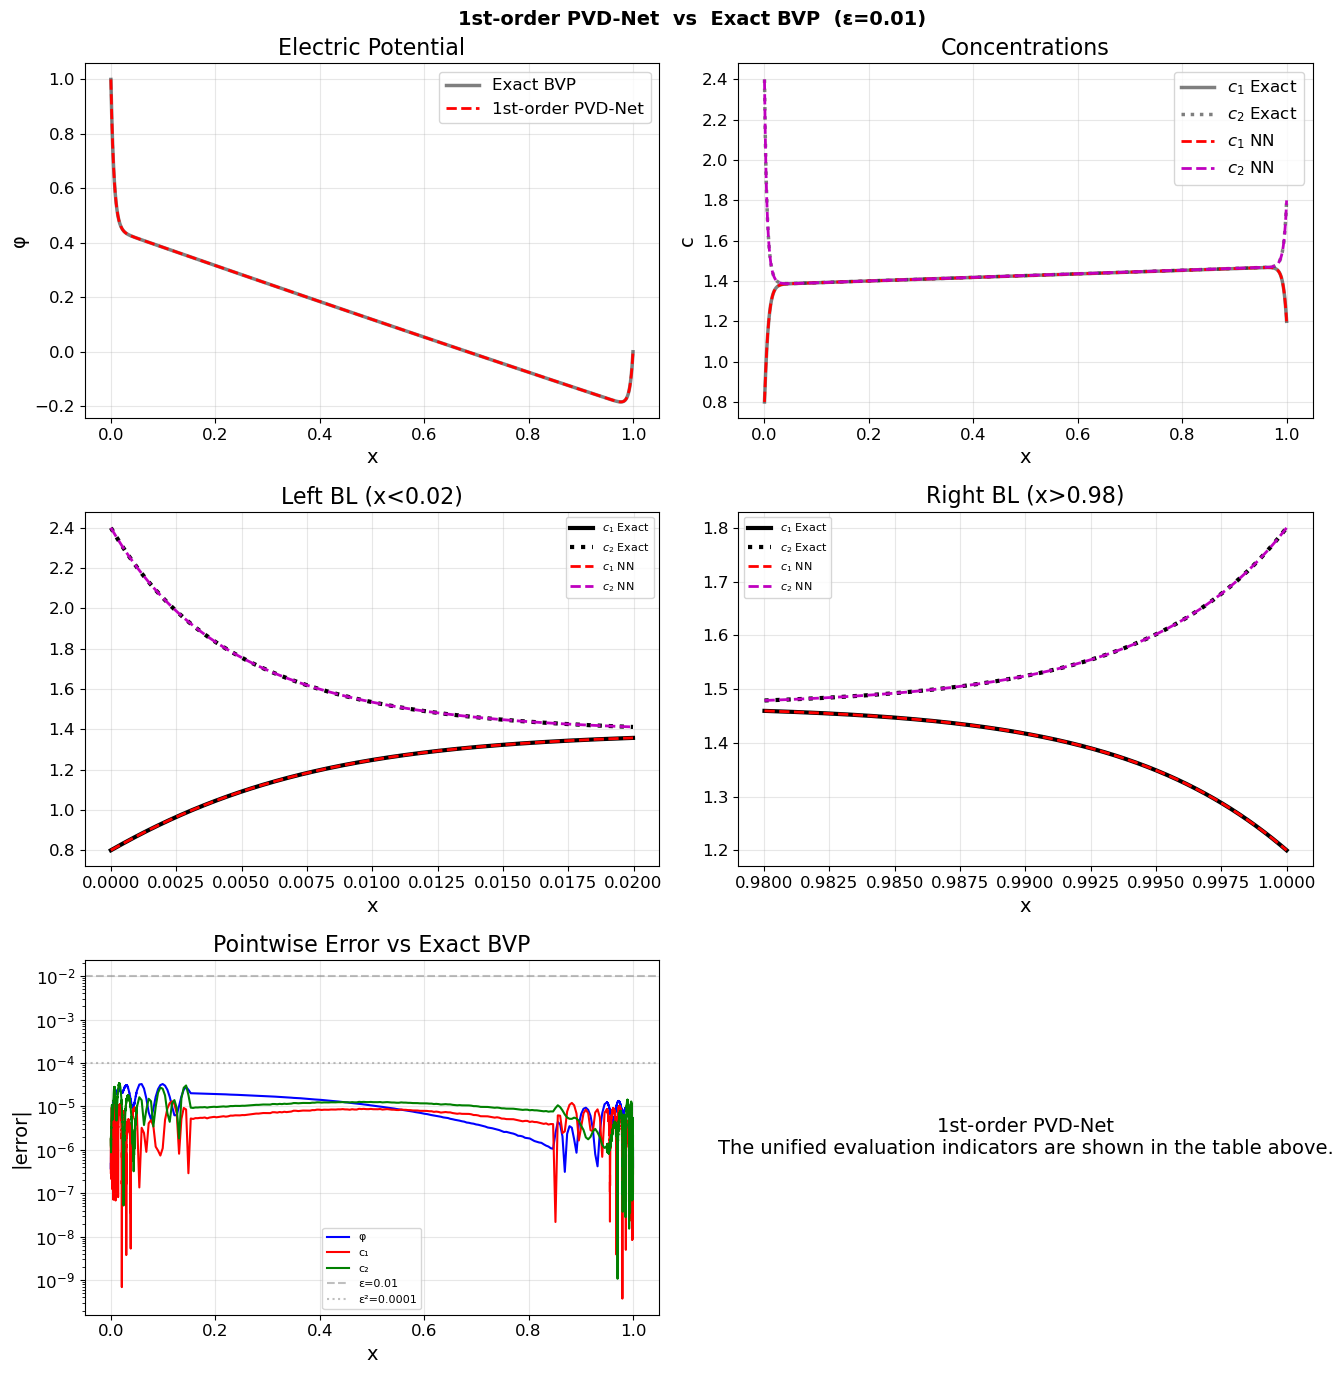

In [17]:
# 绘图
fig_eval = plot_vs_exact(x_eval, phi_nn, c1_nn, c2_nn,
                         phi_ex, c1_ex, c2_ex, eps, '1st-order PVD-Net')


### 10.5 指标说明

| 编号 | 指标名称 | 含义 | 理论预期 |
|------|---------|------|----------|
| ① | 全局相对 L² | 整体逼近质量 | ~ O(ε²) |
| ② | 全局 L∞ | 最坏情形误差 | ~ O(ε²) |
| ③ | 边界层相对 L² | BL 分辨能力 | ~ O(ε²) |
| ④ | 过渡区 L∞ | 内外解拼接质量 | ~ O(ε²) |

该表与零阶 PVD-Net notebook 使用 **完全相同的 6 项指标和精确参考解**, 可直接对比。

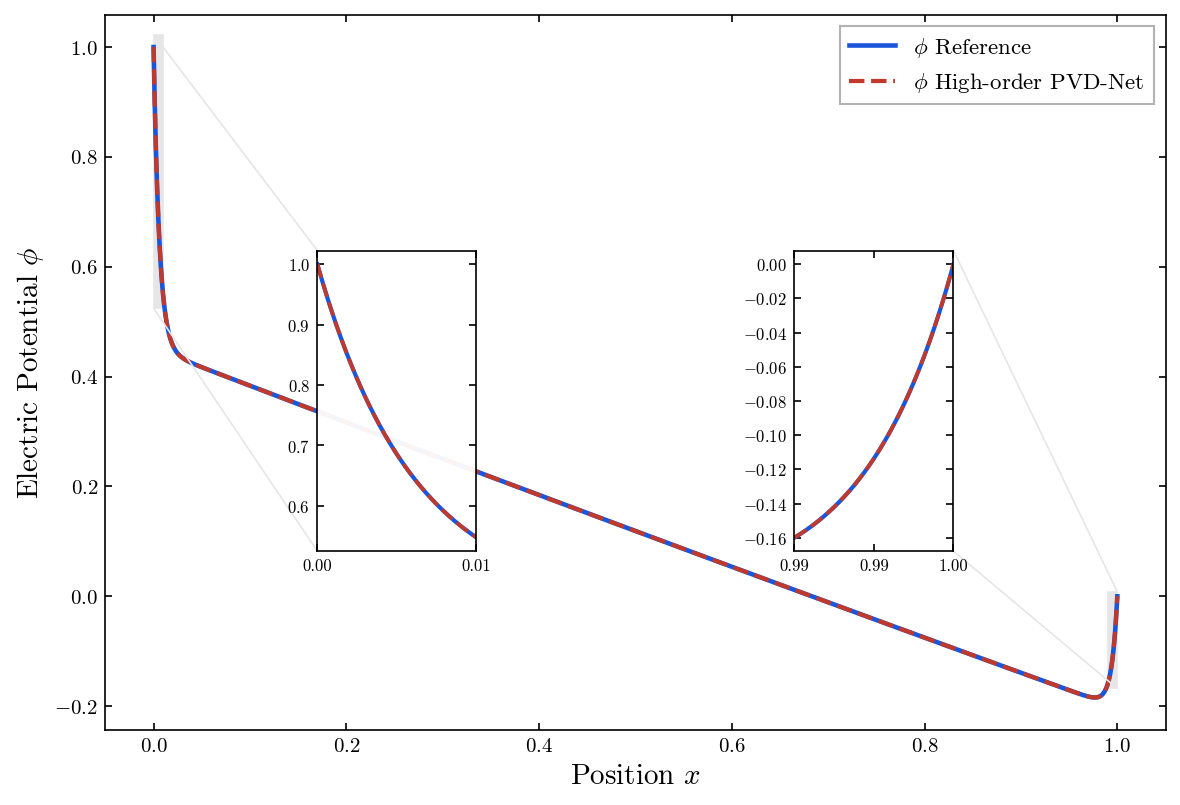

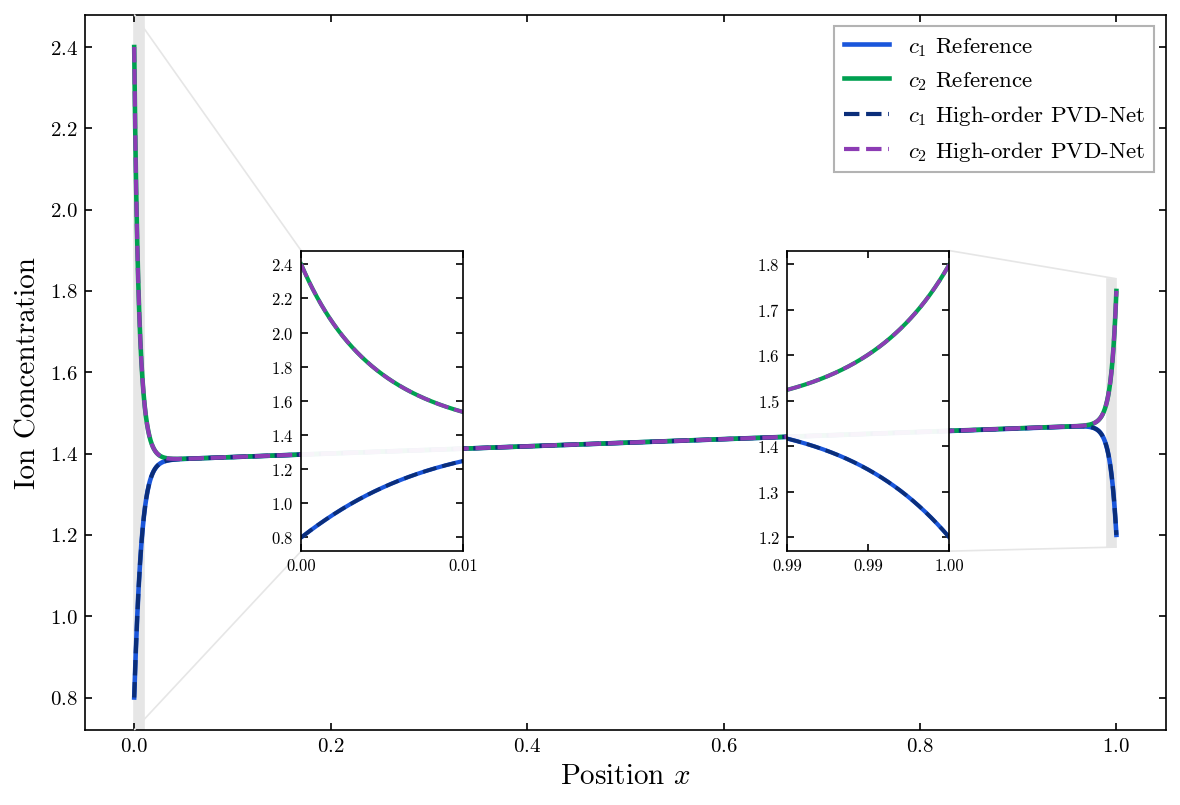

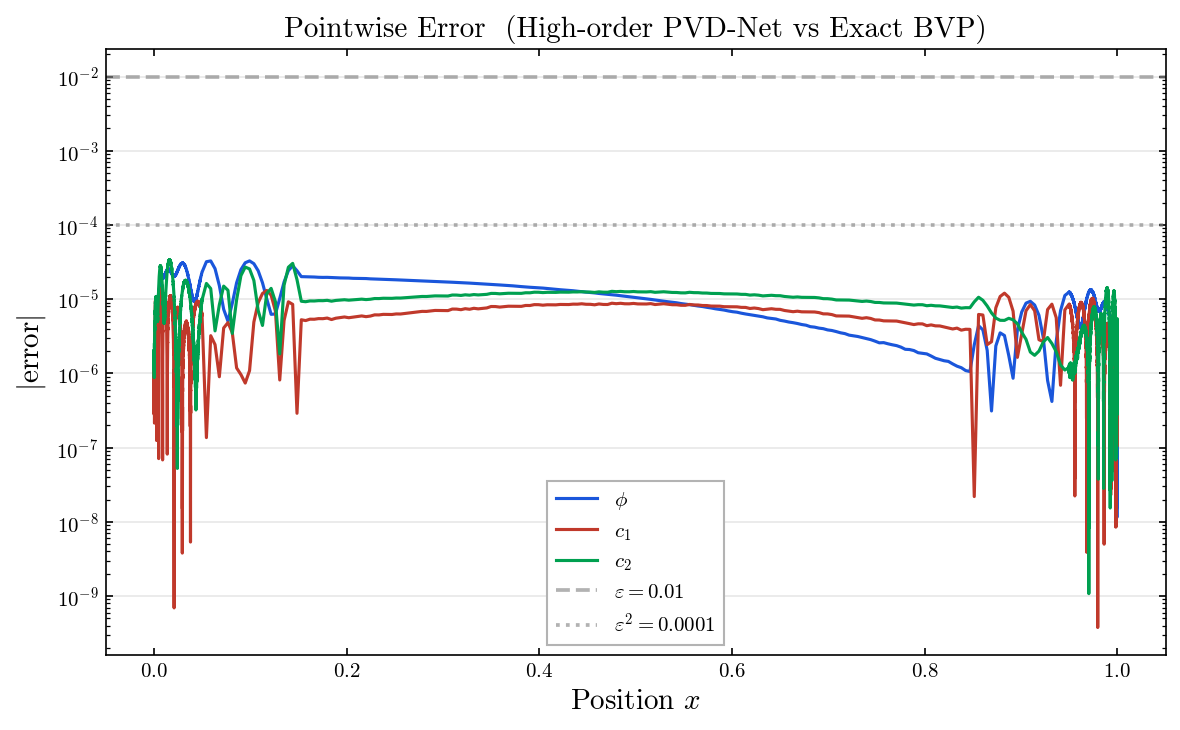

In [18]:
"""
plot_inset.py  —  带边界层放大嵌入图的可视化函数
替换原 notebook 中的 plot_vs_exact，将 c₁/c₂ 和边界层放大图合到同一张图中。
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ============================================================
# Colors matching the TikZ diagram palette
# ============================================================
BLUE    = '#1a56db'   # reference / c1 exact
RED     = '#c0392b'   # NN / c1 NN
GREEN   = '#00a050'   # c2 exact (or error φ)
PURPLE  = '#8c3cb4'   # c2 NN
ORANGE  = '#e67e22'   # error c2
BLUE_D  = '#0b2e7a'   # darker blue variant
GREEN_D = '#005c2e'   # darker green variant


def plot_with_inset(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex,
                    eps, method_name,
                    bl_left=0.01, bl_right=0.990,
                    save_path=None):
    """
    生成两张图:
      图1: 电势 φ —— 主图 + 左/右边界层放大
      图2: 浓度 c₁, c₂ —— 主图 + 左/右边界层放大
    每张图的风格与 TikZ 通道示意图一致。

    参数:
        x            : 评估网格 (1-D array)
        phi_nn, ...  : NN 解
        phi_ex, ...  : 精确解
        eps          : Debye 长度参数
        method_name  : 图例标签
        bl_left      : 左边界层放大截止 x 值
        bl_right     : 右边界层放大起始 x 值
        save_path    : 若给出，保存 PNG/PDF
    """

    figs = []
    mask_L = x <= bl_left
    mask_R = x >= bl_right

    # helper: inset tick style
    def _style_inset(ins):
        ins.tick_params(labelsize=8, direction='in')
        ins.patch.set_alpha(0.95)

    # ================================================================
    #  图1: 电势 φ
    # ================================================================
    fig1, ax1 = plt.subplots(figsize=(8, 5.5))
    ax1.plot(x, phi_ex, color=BLUE, ls='-',  lw=2.2, label=r'$\phi$ Reference')
    ax1.plot(x, phi_nn, color=RED,  ls='--', lw=2.0, label=rf'$\phi$ {method_name}')
    ax1.set_xlabel(r'Position $x$')
    ax1.set_ylabel(r'Electric Potential $\phi$')
    ax1.legend(loc='upper right')

    # ---- 左边界层放大 ----
    if np.any(mask_L):
        ax_inL = ax1.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_inL.plot(x[mask_L], phi_ex[mask_L], color=BLUE, ls='-',  lw=2)
        ax_inL.plot(x[mask_L], phi_nn[mask_L], color=RED,  ls='--', lw=1.8)
        ax_inL.set_xlim(0, bl_left)
        ax_inL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_inL.set_xticks([0, bl_left])
        _style_inset(ax_inL)
        mark_inset(ax1, ax_inL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    # ---- 右边界层放大 ----
    if np.any(mask_R):
        ax_inR = ax1.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_inR.plot(x[mask_R], phi_ex[mask_R], color=BLUE, ls='-',  lw=2)
        ax_inR.plot(x[mask_R], phi_nn[mask_R], color=RED,  ls='--', lw=1.8)
        ax_inR.set_xlim(bl_right, 1)
        ax_inR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_inR)
        mark_inset(ax1, ax_inR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig1.tight_layout()
    figs.append(fig1)

    # ================================================================
    #  图2: 浓度 c₁, c₂
    # ================================================================
    fig2, ax2 = plt.subplots(figsize=(8, 5.5))
    ax2.plot(x, c1_ex, color=BLUE,   ls='-',  lw=2.2, label=r'$c_1$ Reference')
    ax2.plot(x, c2_ex, color=GREEN,  ls='-',  lw=2.2, label=r'$c_2$ Reference')
    ax2.plot(x, c1_nn, color=BLUE_D, ls='--', lw=2.0, label=rf'$c_1$ {method_name}')
    ax2.plot(x, c2_nn, color=PURPLE, ls='--', lw=2.0, label=rf'$c_2$ {method_name}')
    ax2.set_xlabel(r'Position $x$')
    ax2.set_ylabel('Ion Concentration')
    ax2.legend(loc='best')

    # ---- 左边界层放大 ----
    if np.any(mask_L):
        ax_cL = ax2.inset_axes([0.2, 0.25, 0.15, 0.42])
        ax_cL.plot(x[mask_L], c1_ex[mask_L], color=BLUE,   ls='-',  lw=2)
        ax_cL.plot(x[mask_L], c2_ex[mask_L], color=GREEN,  ls='-',  lw=2)
        ax_cL.plot(x[mask_L], c1_nn[mask_L], color=BLUE_D, ls='--', lw=1.8)
        ax_cL.plot(x[mask_L], c2_nn[mask_L], color=PURPLE, ls='--', lw=1.8)
        ax_cL.set_xlim(0, bl_left)
        ax_cL.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax_cL.set_xticks([0, bl_left])
        _style_inset(ax_cL)
        mark_inset(ax2, ax_cL, loc1=2, loc2=3, fc="0.9", ec="0.9", lw=0.8)

    # ---- 右边界层放大 ----
    if np.any(mask_R):
        ax_cR = ax2.inset_axes([0.65, 0.25, 0.15, 0.42])
        ax_cR.plot(x[mask_R], c1_ex[mask_R], color=BLUE,   ls='-',  lw=2)
        ax_cR.plot(x[mask_R], c2_ex[mask_R], color=GREEN,  ls='-',  lw=2)
        ax_cR.plot(x[mask_R], c1_nn[mask_R], color=BLUE_D, ls='--', lw=1.8)
        ax_cR.plot(x[mask_R], c2_nn[mask_R], color=PURPLE, ls='--', lw=1.8)
        ax_cR.set_xlim(bl_right, 1)
        ax_cR.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        _style_inset(ax_cR)
        mark_inset(ax2, ax_cR, loc1=1, loc2=4, fc="0.9", ec="0.9", lw=0.8)

    fig2.tight_layout()
    figs.append(fig2)

    # ================================================================
    #  图3: 逐点误差 (semilogy)
    # ================================================================
    fig3, ax3 = plt.subplots(figsize=(8, 5))
    for var, u_nn, u_ex, clr in [(r'$\phi$', phi_nn, phi_ex, BLUE),
                                  (r'$c_1$', c1_nn,  c1_ex,  RED),
                                  (r'$c_2$', c2_nn,  c2_ex,  GREEN)]:
        ax3.semilogy(x, np.abs(u_nn - u_ex) + 1e-16, color=clr, ls='-',
                     lw=1.5, label=var)
    ax3.axhline(eps,    color='gray', ls='--', alpha=0.6,
                label=rf'$\varepsilon={eps}$')
    ax3.axhline(eps**2, color='gray', ls=':',  alpha=0.6,
                label=rf'$\varepsilon^2={eps**2}$')
    ax3.set_xlabel(r'Position $x$')
    ax3.set_ylabel(r'$|$error$|$')
    ax3.set_title(rf'Pointwise Error  ({method_name} vs Exact BVP)',
                  fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    fig3.tight_layout()
    figs.append(fig3)

    # ---- 保存 ----
    if save_path:
        names = ['phi', 'concentration', 'error']
        for i, fig in enumerate(figs):
            fig.savefig(f'{save_path}_{names[i]}.pdf', bbox_inches='tight')
            fig.savefig(f'{save_path}_{names[i]}.png', bbox_inches='tight')

    plt.show()
    return figs

figs = plot_with_inset(x_eval, phi_nn, c1_nn, c2_nn,
                         phi_ex, c1_ex, c2_ex, eps, 'High-order PVD-Net')

# High-order PVD-Net —— Setting C (Li–Pan–Song–Zhang, 松弛电中性)

$$\varepsilon^2\phi''=-(c_1-c_2),\qquad c_1'+c_1\phi'=-J_1,\qquad c_2'-c_2\phi'=-J_2$$

| | |
|---|---|
| 离子 | $n=2$, $\alpha_1=-\alpha_2=1$ |
| 通道 | $h\equiv1$,  永久电荷 $Q\equiv0$ |
| 松弛参数 | $\sigma=1/3$, $\rho=2/3$, $L=2.4$, $R=1.8$ |
| 边界条件 | $V=1$, $L_1=\sigma L=0.8$, $L_2=L=2.4$, $R_1=\rho R=1.2$, $R_2=R=1.8$ |
| 摄动参数 | $\varepsilon=10^{-2}$ |
| 训练步数 | $3\times10^5$ (分段: $5\times10^4+5\times10^4+2\times10^5$) |

与 Setting A 的微分方程结构完全相同, 仅边界条件不同; 用于检验方法的精度
不依赖于特定的边界取值。两端 $L_1\neq L_2$、$R_1\neq R_2$, 故 $l,r\neq0$,
一阶修正非零。


import copy, time

N_RUNS = 5

# ---- 精确解只算一次 ----
print('求解精确参考解 ...')
sol_exact = compute_exact_reference(eps, V, L1, L2, R1, R2)
grids = create_evaluation_grid(eps)
x_eval = grids['x']
y_ex = sol_exact.sol(x_eval)
phi_ex, c1_ex, c2_ex = y_ex[0], y_ex[2], y_ex[3]
J1_ex, J2_ex = y_ex[4, 0], y_ex[5, 0]
print(f'精确解通量: J1={J1_ex:.6f}, J2={J2_ex:.6f}')

# ---- 收集指标 ----
all_metrics = []
all_times = []

SEEDS = [0, 1, 2, 3, 4]          # 固定随机种子, 保证可复现

for run in range(N_RUNS):
    torch.manual_seed(SEEDS[run])
    np.random.seed(SEEDS[run])
    print(f'\n{"="*50}')
    print(f'  Run {run+1}/{N_RUNS}')
    print(f'{"="*50}')
    t0 = time.time()

    # 每次重新创建模型 (随机初始化不同)
    model_i = create_pvdnet(eps, hidden=33, layers=5, device=DEVICE)
    history_i = train(model_i, V, L1, L2, R1, R2, epochs=300000, log_interval=30000)

    elapsed = time.time() - t0
    all_times.append(elapsed)

    # 评估
    x_t = torch.tensor(x_eval.reshape(-1,1), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        phi_nn, c1_nn, c2_nn = forward_pvdnet(model_i, x_t)
    phi_nn = phi_nn.cpu().numpy().flatten()
    c1_nn = c1_nn.cpu().numpy().flatten()
    c2_nn = c2_nn.cpu().numpy().flatten()

    J10_nn, J20_nn, J11_nn, J21_nn = get_flux(model_i)
    J1_nn = J10_nn + eps * J11_nn
    J2_nn = J20_nn + eps * J21_nn

    m = compute_unified_metrics(
        phi_nn, c1_nn, c2_nn, J1_nn, J2_nn,
        phi_ex, c1_ex, c2_ex, J1_ex, J2_ex, grids)
    all_metrics.append(m)
    print(f'  用时 {elapsed:.1f}s  |  全局相对L²(φ)={m["phi"]["global_rel_L2"]:.4e}')

print(f'\n全部 {N_RUNS} 次实验完成!')
# ---- 汇总统计 ----
metric_keys = ['global_rel_L2', 'global_Linf', 'inner_rel_L2', 'inner_Linf', 'junction_err']
metric_labels = ['① 全局相对 L²', '② 全局 L∞', '③ 内区域相对 L²', '④ 内区域 L∞', '⑤ 交界点误差']
var_names = ['phi', 'c1', 'c2']

print(f'\n{"="*80}')
print(f'  一阶 PVD-Net  {N_RUNS} 次随机实验统计  (ε = {eps})')
print(f'{"="*80}')
print(f'{"指标":<22s} | {"phi (mean±std)":>24s} | {"c1 (mean±std)":>24s} | {"c2 (mean±std)":>24s}')
print(f'{"-"*22}-+-{"-"*24}-+-{"-"*24}-+-{"-"*24}')

for mk, ml in zip(metric_keys, metric_labels):
    row = []
    for v in var_names:
        vals = np.array([m[v][mk] for m in all_metrics])
        row.append(f'{vals.mean():.4e} ± {vals.std():.4e}')
    print(f'{ml:<22s} | {row[0]:>24s} | {row[1]:>24s} | {row[2]:>24s}')

print(f'{"-"*22}-+-{"-"*24}-+-{"-"*24}-+-{"-"*24}')

# 通量统计
#J1_vals = np.array([m['flux']['J1_rel_err'] for m in all_metrics])
#J2_vals = np.array([m['flux']['J2_rel_err'] for m in all_metrics])
#I_vals = np.array([m['current']['I_rel_err'] for m in all_metrics])
#print(f'\n  J1 相对误差: {J1_vals.mean():.4e} ± {J1_vals.std():.4e}')
#print(f'  J2 相对误差: {J2_vals.mean():.4e} ± {J2_vals.std():.4e}')
#print(f'  I  相对误差: {I_vals.mean():.4e} ± {I_vals.std():.4e}')
#print(f'\n  平均训练用时: {np.mean(all_times):.1f}s ± {np.std(all_times):.1f}s')
